## Generate prompts

In [6]:
%cd ..
%pwd  # should be "llm-adaptation"

C:\Users\micha\OneDrive - Univerzita Karlova\research\2024-LLM-DEECo\llm-adaptation


C:\Users\micha\OneDrive - Univerzita Karlova\research\2024-LLM-DEECo\llm-adaptation\.venv\Lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


'C:\\Users\\micha\\OneDrive - Univerzita Karlova\\research\\2024-LLM-DEECo\\llm-adaptation'

In [14]:
!python main.py farm/configs/default.yaml farm/configs/config_no_battery.yaml generated_adaptations/jinja_prompt_generator.yaml DSL/drones.yaml farm/configs/simulation_description_2.yaml

Config:

example: farm
steps: 300
adaptation_params:
  adapt_every: 10
  config: true
  prompt_template_params:
    components:
      Field:
        id: id
        attributes:
          location:
            name: top, bottom, left, right
            description: rectangle
            if: 'lambda component: False'
            hide_in_generate: true
          left:
            name: left
            format: '{:d}'
          top:
            name: top
          right:
            name: right
          bottom:
            name: bottom
          threat_level:
            name: threat level
            format: '{:.2f}'
            description: bird-threat level between 0 and 1
          necessary_drones_for_full_protection:
            name: for full protection
            format: '{:d} drones'
          arriving_drones:
            name: flying to field
            format: 'lambda value: f''{value:d} drone{"s" if value != 1 else ""}'''
            description: number of drones flying towar

In [13]:
!python main.py farm/configs/default.yaml farm/configs/config_no_battery.yaml generated_adaptations/jinja_prompt_generator.yaml DSL/drones.yaml farm/configs/simulation_description_2.yaml farm/configs/strategy.yaml

Config:

example: farm
steps: 300
adaptation_params:
  adapt_every: 10
  config: true
  prompt_template_params:
    components:
      Field:
        id: id
        attributes:
          location:
            name: top, bottom, left, right
            description: rectangle
            if: 'lambda component: False'
            hide_in_generate: true
          left:
            name: left
            format: '{:d}'
          top:
            name: top
          right:
            name: right
          bottom:
            name: bottom
          threat_level:
            name: threat level
            format: '{:.2f}'
            description: bird-threat level between 0 and 1
          necessary_drones_for_full_protection:
            name: for full protection
            format: '{:d} drones'
          arriving_drones:
            name: flying to field
            format: 'lambda value: f''{value:d} drone{"s" if value != 1 else ""}'''
            description: number of drones flying towar

In [12]:
!python main.py farm/configs/default.yaml farm/configs/config_no_battery.yaml generated_adaptations/jinja_prompt_generator.yaml DSL/drones.yaml farm/configs/simulation_description_2.yaml farm/configs/goal_step_by_step.yaml

Config:

example: farm
steps: 300
adaptation_params:
  adapt_every: 10
  config: true
  prompt_template_params:
    components:
      Field:
        id: id
        attributes:
          location:
            name: top, bottom, left, right
            description: rectangle
            if: 'lambda component: False'
            hide_in_generate: true
          left:
            name: left
            format: '{:d}'
          top:
            name: top
          right:
            name: right
          bottom:
            name: bottom
          threat_level:
            name: threat level
            format: '{:.2f}'
            description: bird-threat level between 0 and 1
          necessary_drones_for_full_protection:
            name: for full protection
            format: '{:d} drones'
          arriving_drones:
            name: flying to field
            format: 'lambda value: f''{value:d} drone{"s" if value != 1 else ""}'''
            description: number of drones flying towar

## Run generated

In [1]:
import subprocess
import os
import sys
from pathlib import Path
import textwrap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
farm_configs = ["farm/configs/default.yaml", "generated_adaptations/configs/generated.yaml", "farm/configs/config_no_battery.yaml"]
#farm_variants = [f"{llm}_{variant}_1" for llm in ("4o", "o3") for variant in ("default", "sd1", "step-by-step", "strategy")]
farm_variants_v1 = [f"{llm}_{variant}_{repeat}" for llm in ("4o", "o3") for variant in ("sd2", "sd2_step-by-step", "sd2_strategy") for repeat in range(2, 5)]
farm_variants_v2 = [f"{llm}_{variant}_{repeat}_v2" for llm in ("4o", "o3") for variant in ("sd2", "sd2_step-by-step", "sd2_strategy") for repeat in range(2, 5)]

In [9]:
farm_variants = farm_variants_v1 + farm_variants_v2

### Prepare configuration files

In [10]:
# prepare configuration files
for variant in farm_variants:
    variant_path = Path(f"generated_adaptations/configs/farm/{variant}.yaml")
    if not variant_path.exists():
        variant_path.write_text(f"""name: {variant}
log_dir.append: /{variant}
adaptation_name: generated_adaptations.farm.{variant}.SmartFarmAdaptation
adaptation_params:
  adapt_every: 10""")


In [11]:
# prepare python files
for variant in farm_variants:
    variant_path = Path(f"generated_adaptations/farm/{variant}.py")
    if not variant_path.exists():
        variant_path.parent.mkdir(parents=True, exist_ok=True)
        variant_path.write_text("")

### Run

In [17]:
def run(configs, repeats=10, start=1):
    print(configs)
    damages = []
    for repeat in range(repeats):
        print(f"  Run #{repeat + start}/{repeats + start - 1}")

        run_args = [sys.executable, "main.py", *configs, "-s", str(repeat + start), "-e", str(repeat + start)]
        # if repeat % 10 == 0:
        #     run_args.append("--animation")

        # disable TF errors
        env = dict(os.environ, TF_CPP_MIN_LOG_LEVEL="3")

        result = subprocess.run(run_args, capture_output=True, env=env)
        stdout = result.stdout.decode("utf-8")
        stderr = result.stderr.decode("utf-8")

        if stderr:
            stderr_lines = stderr.splitlines()
            stderr = '\n'.join(stderr_lines[-5:])
            print(f"    StdErr: {len(stderr_lines)} lines")
            print(textwrap.indent(stderr, "    "))

        try:
            damage = stdout.partition("damage: ")[2].partition("\n")[0]
            print(f"    Damage: {damage}")
            damages.append(int(damage))
        except ValueError:
            pass

    if len(damages) > 0:
        avg_damage = sum(damages) / len(damages)
        print(f"Average damage: {avg_damage:.1f}")
    else:
        avg_damage = None
    if repeats != len(damages):
        print(f"Errors: {repeats - len(damages)}")
    print()

    return avg_damage

In [18]:
results = pd.DataFrame(columns=["variant", "damage"])

for variant in farm_variants_v1:
    configs = farm_configs + [f"generated_adaptations/configs/farm/{variant}.yaml"]
    dmg = run(configs, repeats=2, start=4)
    results.loc[len(results)] = [variant, dmg]

['farm/configs/default.yaml', 'generated_adaptations/configs/generated.yaml', 'farm/configs/config_no_battery.yaml', 'generated_adaptations/configs/farm/4o_sd2_2.yaml']
  Run #4/5
    StdErr: 29 lines
    The following components have not been assigned to a group: Drone_1, Drone_2, Drone_3, Drone_4, Drone_5, Drone_6, Drone_7, Drone_8
    The following components have not been assigned to a group: Drone_1, Drone_2, Drone_3, Drone_4, Drone_5, Drone_6, Drone_7, Drone_8
    The following components have not been assigned to a group: Drone_1, Drone_2, Drone_3, Drone_4, Drone_5, Drone_6, Drone_7, Drone_8
    The following components have not been assigned to a group: Drone_1, Drone_2, Drone_3, Drone_4, Drone_5, Drone_6, Drone_7, Drone_8
    The following components have not been assigned to a group: Drone_1, Drone_2, Drone_3, Drone_4, Drone_5, Drone_6, Drone_7, Drone_8
    Damage: 216
  Run #5/5
    StdErr: 29 lines
    The following components have not been assigned to a group: Drone_1, Dro

In [19]:
results

,variant,damage
0,4o_sd2_2,234.0
1,4o_sd2_3,256.5
2,4o_sd2_4,257.0
3,4o_sd2_step-by-step_2,334.5
4,4o_sd2_step-by-step_3,198.0
5,4o_sd2_step-by-step_4,250.0
6,4o_sd2_strategy_2,250.0
7,4o_sd2_strategy_3,250.0
8,4o_sd2_strategy_4,250.0
9,o3_sd2_2,288.5


In [20]:
for variant in farm_variants_v2:
    configs = farm_configs + [f"generated_adaptations/configs/farm/{variant}.yaml"]
    dmg = run(configs, repeats=2, start=4)
    var = variant.removesuffix("_v2")
    results.loc[results["variant"] == var, "damage_v2"] = dmg

['farm/configs/default.yaml', 'generated_adaptations/configs/generated.yaml', 'farm/configs/config_no_battery.yaml', 'generated_adaptations/configs/farm/4o_sd2_2_v2.yaml']
  Run #4/5
    Damage: 273
  Run #5/5
    Damage: 279
Average damage: 276.0

['farm/configs/default.yaml', 'generated_adaptations/configs/generated.yaml', 'farm/configs/config_no_battery.yaml', 'generated_adaptations/configs/farm/4o_sd2_3_v2.yaml']
  Run #4/5
    StdErr: 29 lines
    The following components have not been assigned to a group: Drone_1, Drone_2, Drone_3, Drone_4, Drone_5, Drone_6, Drone_7, Drone_8
    The following components have not been assigned to a group: Drone_1, Drone_2, Drone_3, Drone_4, Drone_5, Drone_6, Drone_7, Drone_8
    The following components have not been assigned to a group: Drone_1, Drone_2, Drone_3, Drone_4, Drone_5, Drone_6, Drone_7, Drone_8
    The following components have not been assigned to a group: Drone_1, Drone_2, Drone_3, Drone_4, Drone_5, Drone_6, Drone_7, Drone_8
    The

In [7]:
results

NameError: name 'results' is not defined

## Plot the results

In [8]:
results_folder = Path("logs/generated/no_battery")

In [9]:
results_files = sorted(results_folder.glob("*/*.csv"))
print(len(results_files), "files found")

180 files found


In [37]:
summary = pd.DataFrame(columns=["llm", "params", "repeat", "version", "damage"])

In [28]:
allowed_params = {
    "strategy": "Hinted",
    "step-by-step": "Step-by-Step",
}

In [38]:
for file in results_files:
    try:
        name = file.stem

        data = pd.read_csv(file)
        damage = data.iloc[299]["damage"]  # 300th step

        parts = name.split("_")
        llm = parts[0].split("-")[-1]
        if parts[-1] == "v2":
            version = 2
            parts.pop()
        else:
            version = 1

        repeat = int(parts[-1])
        parts.pop()

        params = []
        for param in allowed_params:
            if param in name:
                params.append(allowed_params[param])
        if params == []:
            params = ["Default"]
        params = ",\n".join(params)

        summary.loc[len(summary)] = [llm, params, repeat, version, damage]
    except pd.errors.EmptyDataError:
        print("Skipping empty file", file)
    except IndexError:
        print("Index error in file", file)

summary.to_csv(results_folder / "summary.csv", index=False)

Index error in file logs\generated\no_battery\4o_sd2_strategy_4_v2\001-2025-03-11-11-34-50-4o_sd2_strategy_4_v2.csv
Index error in file logs\generated\no_battery\4o_sd2_strategy_4_v2\002-2025-03-11-17-23-49-4o_sd2_strategy_4_v2.csv
Index error in file logs\generated\no_battery\4o_sd2_strategy_4_v2\003-2025-03-11-17-23-55-4o_sd2_strategy_4_v2.csv
Index error in file logs\generated\no_battery\4o_sd2_strategy_4_v2\004-2025-03-11-17-53-18-4o_sd2_strategy_4_v2.csv
Index error in file logs\generated\no_battery\4o_sd2_strategy_4_v2\005-2025-03-11-17-53-29-4o_sd2_strategy_4_v2.csv


In [10]:
summary = pd.read_csv(results_folder / "summary.csv")
summary

,llm,params,repeat,version,damage
0,4o,Default,2,1,291
1,4o,Default,2,1,272
2,4o,Default,2,1,293
3,4o,Default,2,1,216
4,4o,Default,2,1,252
...,...,...,...,...,...
170,o3,Hinted,4,2,264
171,o3,Hinted,4,2,206
172,o3,Hinted,4,2,280
173,o3,Hinted,4,2,245


In [11]:
palette = {
    "4o": "tab:orange",
    "o3": "tab:pink",
}

In [12]:
llm_names = {
    "4o": "GPT-4o",
    "o3": "OpenAI o3-mini",
}
summary['LLM'] = summary['llm'].map(llm_names)
palette_LLM = {v: palette[k] for k, v in llm_names.items()}

In [13]:
summary_v1 = summary[summary["version"] == 1]
summary_v2 = summary[summary["version"] == 2]

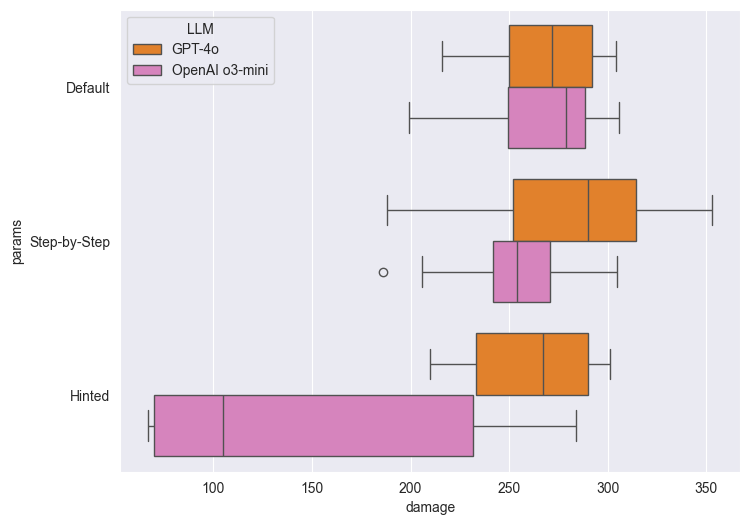

In [16]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(x="damage", y="params", hue="LLM", data=summary_v1, ax=ax, palette=palette_LLM, hue_order=palette_LLM.keys())
plt.show()

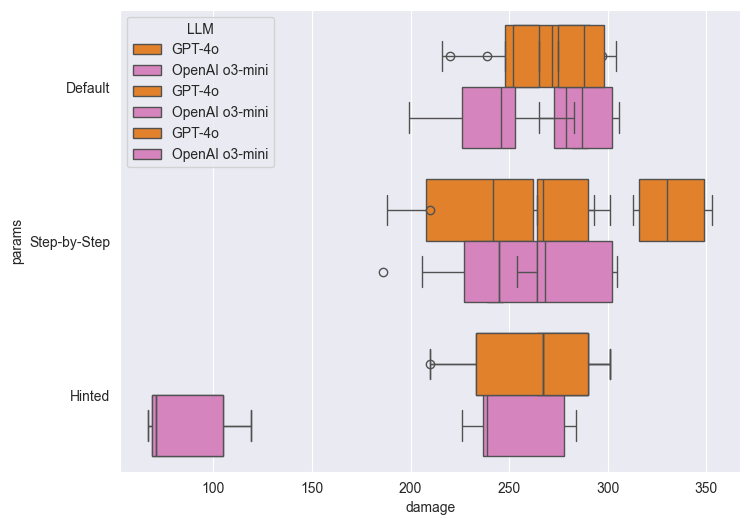

In [17]:
fig, ax = plt.subplots(figsize=(8, 6))
for repeat in range(2, 5):
    data = summary_v1[summary_v1["repeat"] == repeat]
    sns.boxplot(x="damage", y="params", hue="LLM", data=data, ax=ax, palette=palette_LLM, hue_order=palette_LLM.keys(), dodge=True)
plt.show()

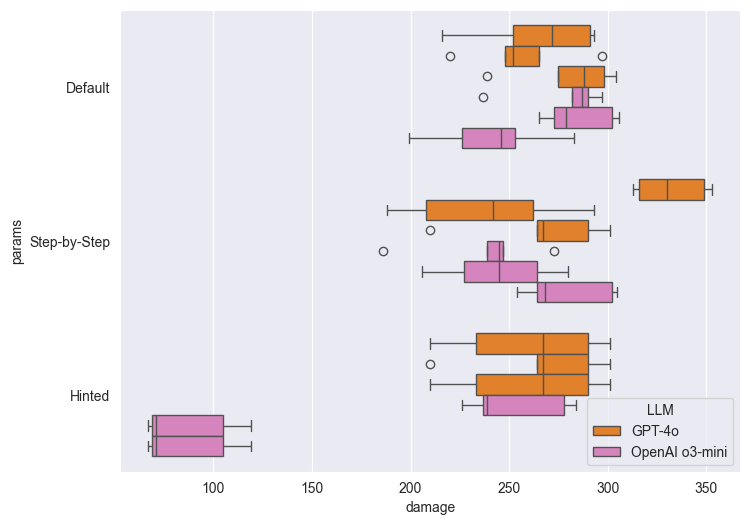

In [18]:
summary["llm_repeat"] = summary["llm"] + "_" + summary["repeat"].astype(str)
summary_v1 = summary[summary["version"] == 1]

palette_boxes = {
    "4o_2": "tab:orange",
    "4o_3": "tab:orange",
    "4o_4": "tab:orange",
    "o3_2": "tab:pink",
    "o3_3": "tab:pink",
    "o3_4": "tab:pink",
}

fig, ax = plt.subplots(figsize=(8, 6))
ax_boxes = sns.boxplot(x="damage", y="params", hue="llm_repeat", data=summary_v1, ax=ax, palette=palette_boxes, hue_order=palette_boxes.keys(), dodge=True)

handles, _ = ax_boxes.get_legend_handles_labels()
handles = handles[::3]
labels = ["GPT-4o", "OpenAI o3-mini"]
ax_boxes.get_legend().remove()
legend_llm = plt.legend(handles, labels, title="LLM", loc="lower right")

plt.show()

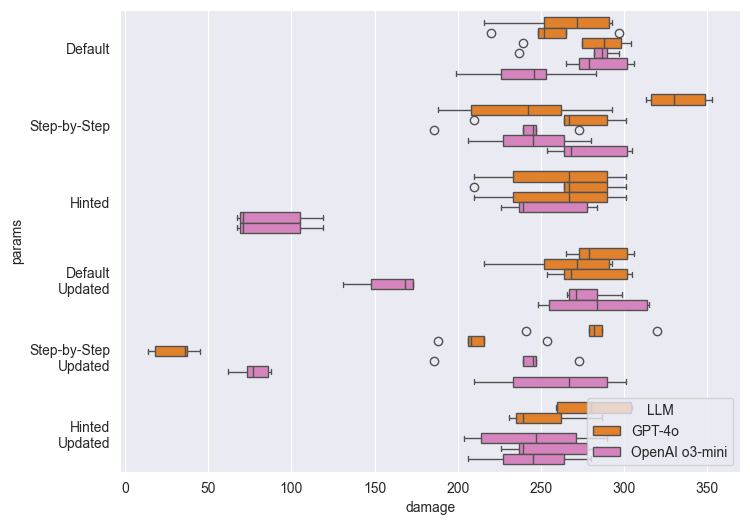

In [21]:
summary_v2 = summary[summary["version"] == 2]
summary_v2.loc[:, "params"] = summary_v2["params"] + "\nUpdated"

fig, ax = plt.subplots(figsize=(8, 6))

ax_boxes = sns.boxplot(x="damage", y="params", hue="llm_repeat", data=summary_v1, ax=ax, palette=palette_boxes, hue_order=palette_boxes.keys(), dodge=True)
sns.boxplot(x="damage", y="params", hue="llm_repeat", data=summary_v2, ax=ax, palette=palette_boxes, hue_order=palette_boxes.keys(), dodge=True)

handles, _ = ax_boxes.get_legend_handles_labels()
handles = handles[::3]
labels = ["GPT-4o", "OpenAI o3-mini"]
ax_boxes.get_legend().remove()
legend_llm = plt.legend(handles, labels, title="LLM", loc="lower right")

plt.show()

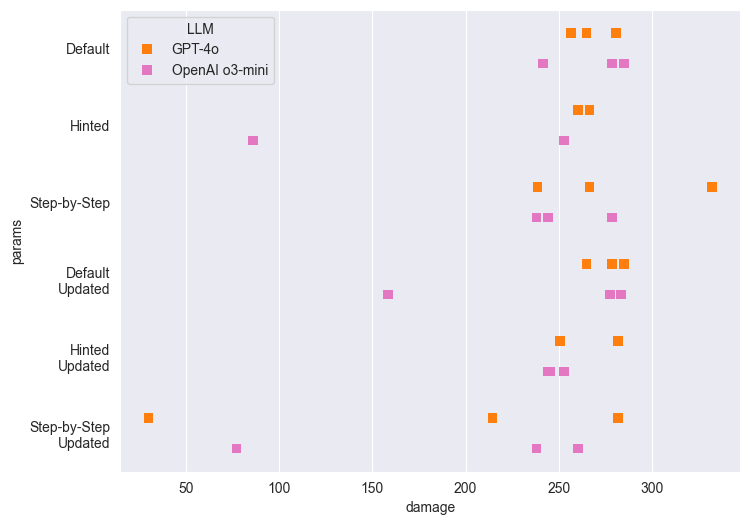

In [36]:
fig, ax = plt.subplots(figsize=(8, 6))
agg_v1 = summary_v1.groupby(["params", "LLM", "repeat"]).agg({"damage": "mean"}).reset_index()
agg_v2 = summary_v2.groupby(["params", "LLM", "repeat"]).agg({"damage": "mean"}).reset_index()
data = pd.concat([agg_v1, agg_v2])
sns.stripplot(x="damage", y="params", hue="LLM", data=data, ax=ax, palette=palette_LLM, hue_order=palette_LLM.keys(), dodge=True, marker="s", jitter=False, size=7)
plt.show()